In [1]:
from simpy_ejector import nozzleSolver,NozzleParams, EjectorGeom, nozzleFactory, fluidProp, EjectorMixer, numSolvers

In [2]:
import numpy as np
import math
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import pandas as pd
import time
import importlib
import logging,sys

In [3]:
logging.basicConfig(stream = sys.stdout, level = logging.DEBUG)
logging.getLogger("matplotlib").setLevel(logging.ERROR)
logging.getLogger("PIL").setLevel(logging.ERROR)

In [4]:
pd.set_option('display.expand_frame_repr', False)
pd.set_option('display.max_rows', 140)
np.core.arrayprint._line_width = 180
np.set_printoptions(linewidth= 180)

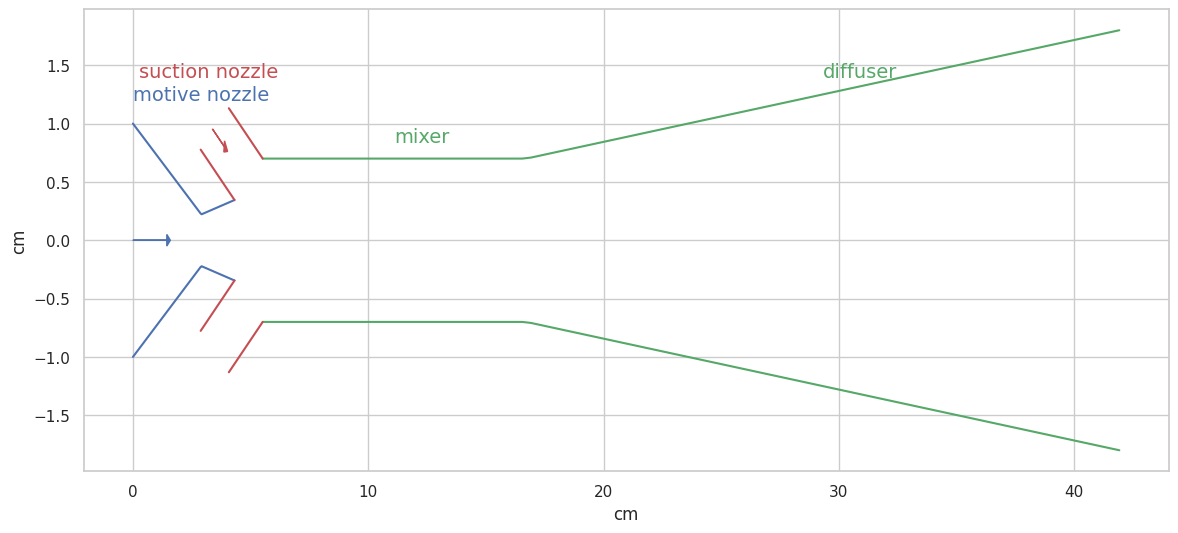

In [5]:
nozzle = nozzleFactory.ConicConic(Rin = 1.0, Lcon=2.905, Rt = 0.2215, Ldiv = 1.4116, Rout = 0.345 )
nozzle.setFriction( 1.0e-2 )
ejector = EjectorGeom(nozzle, Dm = 1.4 )
ejector.setMixer(mixerstart=5.514, mixerLen=11.2, diffuserLen=25.2, diffuserHeight=1.80)
ejectorPlot = ejector.draw()

In [8]:
pin = 2140.0  # kPa  2000
Tin = 273.15 + 114.0  # Kelvin  380
Tsuc =  52.7 + 273.15 #  suction temperature
Psuc =  430 # suction pressure kPa
fluid = "IsoButane"
RP = fluidProp.setup(fluid)
[Din, hin] = fluidProp.getDh_from_TP(RP, Tin, pin)
[DinSuc, hinSuc] = fluidProp.getDh_from_TP(RP, Tsuc, Psuc)
hin, hinSuc

(709.2909050579749, 635.9914487599148)

In [9]:
nsolver = nozzleSolver.NozzleSolver(nozzle, fluid, 1, solver="AdamAdaptive", mode="basic")
nsolver.setFriction(1e-2)
vin_crit = nsolver.calcCriticalSpeed(pin, hin, 0.1, maxdev= 1e-3, chokePos="divergent_part" )

friction of the flow calc set to 0.01
{'massflow': 0.005291458995389667}
DEBUG:root:x: 0.0 stepsize corrected by 121.88973330326192
DEBUG:root:new stepsize = 0.1
DEBUG:root:x: 0.1 stepsize corrected by 54.96804608244039
DEBUG:root:new stepsize = 0.1
DEBUG:root:x: 0.2 stepsize corrected by 50.48993871224869
DEBUG:root:new stepsize = 0.1
DEBUG:root:x: 0.30000000000000004 stepsize corrected by 46.26186326250884
DEBUG:root:new stepsize = 0.1
DEBUG:root:x: 0.4 stepsize corrected by 42.27663800917343
DEBUG:root:new stepsize = 0.1
DEBUG:root:x: 0.5 stepsize corrected by 38.52708122155362
DEBUG:root:new stepsize = 0.1
DEBUG:root:x: 0.6 stepsize corrected by 35.0060111612134
DEBUG:root:new stepsize = 0.1
DEBUG:root:x: 0.7 stepsize corrected by 31.70624608061968
DEBUG:root:new stepsize = 0.1
DEBUG:root:x: 0.7999999999999999 stepsize corrected by 28.620604221499274
DEBUG:root:new stepsize = 0.1
DEBUG:root:x: 0.8999999999999999 stepsize corrected by 25.741903812832792
DEBUG:root:new stepsize = 0.1

In [10]:
vin_crit

5.435742187500001

In [11]:
sol_until_throat = nsolver.solveAdaptive1DBasic(vin_crit, pin, hin, 0.0, nsolver.nozzle.xt)
# In[9]:
dv_kick = 2.0
dp_kick = nsolver.pFromV_MassConst(v = sol_until_throat.iloc[-1]["v"], dv = dv_kick, p = sol_until_throat.iloc[-1]["p"], h = sol_until_throat.iloc[-1]["h"])
print(f"mass conserving artificial kick: dv = {dv_kick} m/s, dp = {dp_kick} kPa")

{'massflow': 0.09587668964888661}
DEBUG:root:x: 2.4499999999999993 stepsize corrected by 0.4027892683321872
DEBUG:root:new stepsize = 0.02013946341660936
DEBUG:root:x: 2.6312551707494842 stepsize corrected by 0.44756980009353564
DEBUG:root:new stepsize = 0.009013815615362927
DEBUG:root:x: 2.7484347737492 stepsize corrected by 0.4897723036999913
DEBUG:root:new stepsize = 0.004414717239063256
DEBUG:root:x: 2.827899684052341 stepsize corrected by 0.49429283144100933
DEBUG:root:new stepsize = 0.0021821630841080118
DEBUG:root:x: 2.875907271902715 stepsize corrected by 0.47566456379362976
DEBUG:root:new stepsize = 0.0010379776515287993
DEBUG:root:x: 2.895628847281762 stepsize corrected by 0.49504015231127074
DEBUG:root:new stepsize = 0.0005138406147085118
DEBUG:root:x: 2.9023087752729753 stepsize corrected by 0.49490940886948553
DEBUG:root:new stepsize = 0.0002543045548785227
DEBUG:root:x: 2.9043432117120043 stepsize corrected by 0.4544056082487758
DEBUG:root:new stepsize = 0.000115557415940

{'massflow': 0.09587668964888661}
DEBUG:root:x: 2.4499999999999993 stepsize corrected by 0.4027892683321872
DEBUG:root:new stepsize = 0.02013946341660936
DEBUG:root:x: 2.6312551707494842 stepsize corrected by 0.44756980009353564
DEBUG:root:new stepsize = 0.009013815615362927
DEBUG:root:x: 2.7484347737492 stepsize corrected by 0.4897723036999913
DEBUG:root:new stepsize = 0.004414717239063256
DEBUG:root:x: 2.827899684052341 stepsize corrected by 0.49429283144100933
DEBUG:root:new stepsize = 0.0021821630841080118
DEBUG:root:x: 2.875907271902715 stepsize corrected by 0.47566456379362976
DEBUG:root:new stepsize = 0.0010379776515287993
DEBUG:root:x: 2.895628847281762 stepsize corrected by 0.49504015231127074
DEBUG:root:new stepsize = 0.0005138406147085118
DEBUG:root:x: 2.9023087752729753 stepsize corrected by 0.49490940886948553
DEBUG:root:new stepsize = 0.0002543045548785227
DEBUG:root:x: 2.9043432117120043 stepsize corrected by 0.4544056082487758
DEBUG:root:new stepsize = 0.000115557415940

/volume1/PROJECTS/MATACHANA/robert/python/simpy_steamEjector/src/simpy_ejector/nozzleSolver.py:419: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  sol_full = sol_1.append(sol_2.iloc[1:], ignore_index=True)


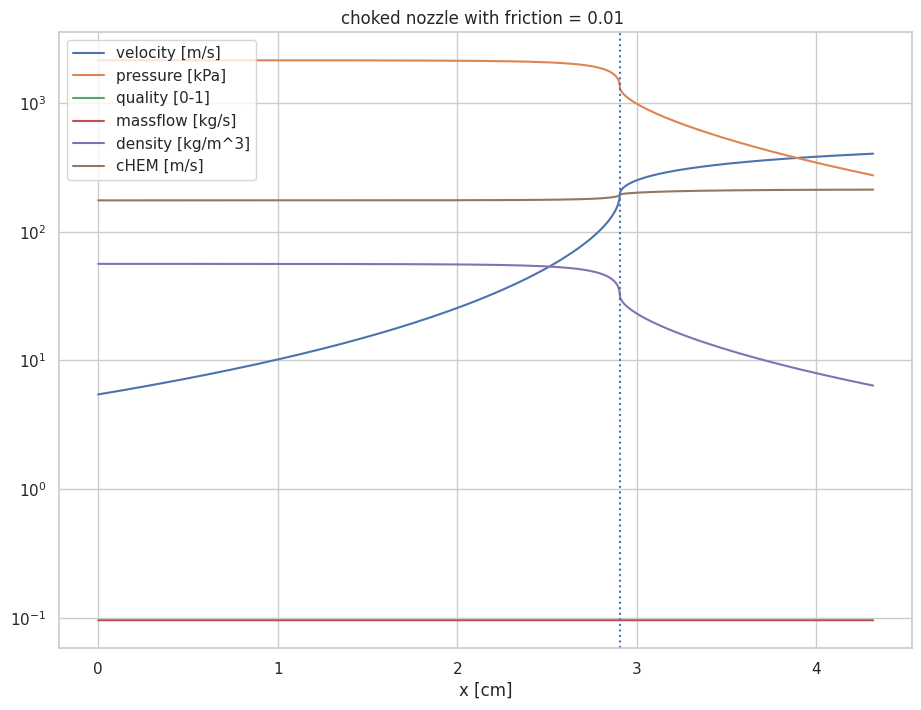

In [12]:
res_crit = nsolver.solveKickedNozzle(vin_crit, pin , hin, kicks = {'v': dv_kick , 'p': -dp_kick})
nsolver.plotsol(res_crit, title = "choked nozzle with friction = {} ".format(nsolver.frictionCoef))


In [13]:
nozzleExit =  res_crit.iloc[-1]
nozzleExit

x            4.316600
v          402.597917
p          273.397534
h          628.648932
d            6.368739
c          211.686835
mach         1.901856
quality      0.000000
Name: 3133, dtype: float64

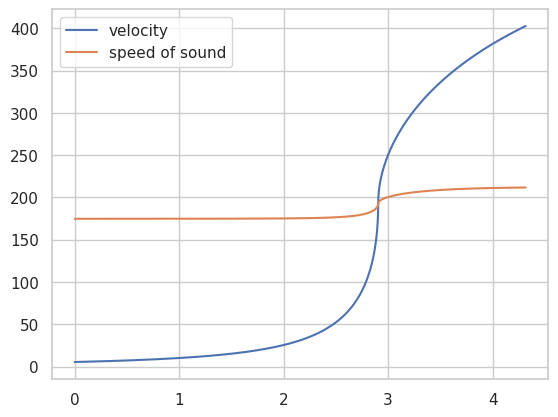

In [14]:
plt.figure()
plt.plot(res_crit['x'], res_crit['v'])
plt.plot(res_crit['x'], res_crit['c'])
plt.legend(["velocity", "speed of sound"])

In [15]:
massFlowPrim = nozzleExit['v']* nozzleExit['d']* nozzle.Aprofile(nozzle.L) * 1e-4
massFlowPrim # in kg/sec

0.09587668964881303

In [16]:
mixingParams = { 'massExchangeFactor' : 1.e-4, 'dragFactor': 0.003, 'frictionInterface': 0.001, 'frictionWall': 0.015}
mixer = EjectorMixer.EjectorMixer(fluid, ejector, mixingParams)

In [17]:
calcSucMassFlow = True
if calcSucMassFlow == False:
    # Single Choking calculation. With externally set suction mass flow rate:
    MFlowSuc = 58.0
    mixer.setSuctionMassFlow(MFlowSuc) # set the suction mass flow rate in [g/s]b

    entrainment = mixer.massFlowSecond / 1000.0 / massFlowPrim
    entrainment

    preMix = mixer.premixWrapSolve(res_crit, Psuc ,Tsuc)
    preMix
    mixerinput = [ preMix[key] for key in [  'py', 'vpy', 'vsy', 'hpy', 'hsy', 'Apy', 'Asy']]

    solMix = mixer.solveMix(mixerinput)
else:
    mixer.setSuctionMassFlow(None)
    mixer.setSingleChoke(True)
    mixer.ejector.Asi = 2* 1.1**2 * math.pi  # cm2 of the suction nozzle inlet.
    #mixer.ejector.Asi = 2*3.14*3.25*2.2
    preMix = mixer.premixWrapSolve(res_crit, Psuc ,Tsuc)
    preMix
    print(f"calculated secondary mass flow rate {preMix['massFlowSecond']} g/s")
    mixerinput = [ preMix[key] for key in [  'py', 'vpy', 'vsy', 'hpy', 'hsy', 'Apy', 'Asy']]
    solMix = mixer.solveMix(mixerinput)

critical flow nozzle outlet quantities
               3133
x          4.316600
v        402.597917
p        273.397534
h        628.648932
d          6.368739
c        211.686835
mach       1.901856
quality    0.000000
INFO:root:suction flow by inlet Dens 10.13456764449752 g/l, quality 0.0
INFO:root:calculation of single-chocking subcritical mode incl. suction mass flow rate calculations
{'Tsi': 325.84999999999997, 'psi': 430, 'massFlowPrim': 95.87668964881303, 'ho': 628.6489319602777, 'vo': 402.5979172412707, 'so': 2.4734978986042107, 'Am': 1.5393804002589984}
INFO:root:solving equation for 10 variables in solvePreMixSingleChoke with parameters:
 {'Tsi': 325.84999999999997, 'psi': 430, 'massFlowPrim': 95.87668964881303, 'ho': 628.6489319602777, 'vo': 402.5979172412707, 'so': 2.4734978986042107, 'Am': 1.5393804002589984, 'sp': 2.4734978986042107, 'Dsi': 10.13456764449752, 'hsi': 635.9914487599148, 'hst': 635.9914487599148, 'sst': 2.4362554911605505, 'Asi': 7.602654221687301}
INFO:root:

In [18]:
print(solMix)

             x           p          vp          vs          hp          hs        Ap        As
0     5.514000  377.926025  366.221771  103.299301  642.632263  630.765930  0.300759  1.238622
1     5.696915  385.749695  355.928351  101.374445  646.411084  630.910703  0.305566  1.233815
2     5.879829  393.056637  346.201437   99.679260  649.877642  631.037491  0.310537  1.228844
3     6.062744  399.897839  336.998453   98.179869  653.063962  631.149865  0.315643  1.223737
4     6.245658  406.316545  328.281321   96.849128  655.998011  631.250526  0.320863  1.218517
..         ...         ...         ...         ...         ...         ...       ...       ...
195  41.182342  600.422538   34.422866    9.620442  703.756991  641.265358  2.475793  7.347369
196  41.365256  600.458219   34.158074    9.527381  703.746008  641.287560  2.495585  7.416478
197  41.548171  600.493120   33.896309    9.435664  703.734942  641.309660  2.515462  7.485902
198  41.731085  600.527261   33.637527    9.345264

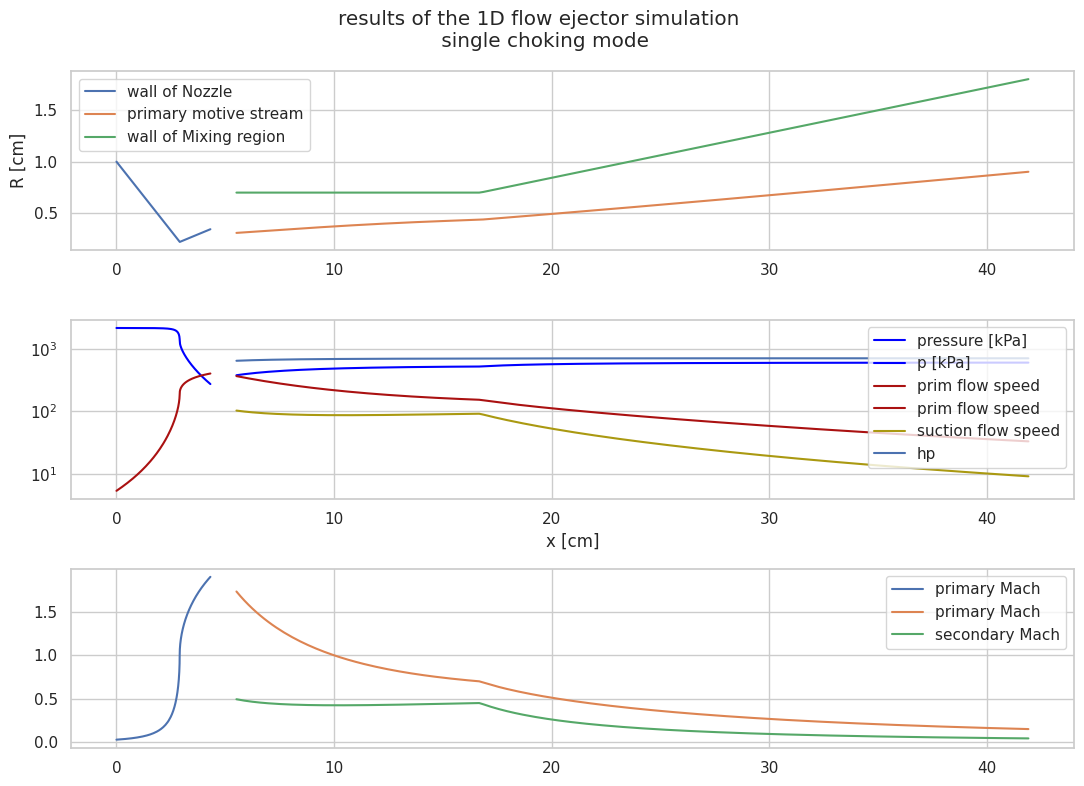

In [19]:
mixer.plotSolution(res_crit, solMix, "single choking mode",  ejectorPlot)

In [20]:
Pdiffout = solMix.iloc[-1]['p']
Pdiffout

600.560661768418

In [21]:
# Ejector Pressure Lift in kPa

Pdiffout - Psuc

170.56066176841796

In [22]:
# Ejector efficiency:

diffusorLast =  solMix.iloc[-1]
diffusorLast

x      41.914000
p     600.560662
vp     33.381682
vs      9.256157
hp    703.712573
hs    641.353558
Ap      2.555468
As      7.625698
Name: 199, dtype: float64

In [24]:
# We need to calculate the average spec enthalpy, for that we need the mass flow rates
primState =  fluidProp.getTD(RP, diffusorLast['hp'] , diffusorLast['p'])
secState = fluidProp.getTD(RP, diffusorLast['hs'] , diffusorLast['p'])
primState, secState

({'T': 89.40628543074342,
  'D': 12.699613598959232,
  'q': 0.0,
  'c': 218.44067361655658,
  's': 2.5894906932107644},
 {'T': 58.601416313699815,
  'D': 14.415621816275959,
  'q': 0.0,
  'c': 202.93236571289822,
  's': 2.4098007813314255})

In [25]:
massFPrim = primState['D'] * diffusorLast['vp']* diffusorLast['Ap']* 1e-4
massFSec = primState['D'] * diffusorLast['vs']* diffusorLast['As']* 1e-4
massFPrim , massFSec

(0.10833511190584011, 0.08963979140343614)

In [26]:
hAverage = (massFPrim * diffusorLast['hp'] + massFSec * diffusorLast['hs'] )/ (massFPrim + massFSec )
hAverage

675.4774327152334

In [27]:
hin,hinSuc,Psuc

(709.2909050579749, 635.9914487599148, 430)

In [28]:
efficiency = mixer.calcEfficiency(pin, Tin, Psuc, Tsuc, Pdiffout, massFPrim , massFSec )

 Expansion work recovered : -58.4915817372128 Watt. 
  max expansion work recovery potential 78.63118323273974 Watt


In [29]:
efficiency

-0.7438725875977737

In [33]:
def specPlotSolution(ejector, RP, solNozzle, solMix, title="", ejectorPlot=True,
                     pressureExp = None):
    """ Plot the results of solveMix function
    :param solNozzle: solution of the nozzle
    :param solMix: the solution dataframe with data that we get from the solveMix function
    :return:
    """
    fig = plt.figure(figsize=[11, 8])
    fig.suptitle("results of the 1D flow ejector simulation \n " + title)
    if (ejectorPlot):
        plt.subplot(311)
        # plt.plot(ejectorPlot)
        nozzleWall = [ejector.nozzle.Rprofile(xi) for xi in solNozzle['x']]
        mixerWall = [ejector.mixerR(xi) for xi in solMix['x']]
        plt.plot(solNozzle['x'], nozzleWall)
        plt.plot(solMix['x'], np.sqrt(solMix['Ap'] / math.pi))
        plt.plot(solMix['x'], mixerWall)
        plt.legend(['wall of Nozzle', 'primary motive stream', 'wall of Mixing region'])
        plt.ylabel("R [cm]")

    if ejectorPlot:
        plt.subplot(312)
    else:
        plt.subplot(211)
    if pressureExp is None:
        plt.plot(solNozzle['x'], solNozzle['p'], color = 'C0')
        plt.plot(solMix['x'], solMix['p'], color='C0')
        # speeds
        plt.plot(solNozzle['x'], solNozzle['v'], color="#aa1111")
        plt.plot(solMix['x'], solMix['vp'], color="#aa1111")
        plt.plot(solMix['x'], solMix['vs'], color="#aa9911")
        ## enthalpy
        plt.plot(solMix['x'], solMix['hp'])
        plt.legend(['pressure [kPa]', 'p [kPa]',
                    'prim flow speed', 'prim flow speed', 'suction flow speed',
                    'hp'])
        plt.yscale("log")
        plt.xlabel("x [cm]")
    else:
        plt.plot(solNozzle['x'], solNozzle['p'], color='C0')
        plt.plot(solMix['x'], solMix['p'], color='C0')
        plt.plot(pressureExp['x'], pressureExp['p'], color = 'red', marker = 'x', linestyle = '')
        plt.legend(['pressure simulation [kPa]', '',
                    'pressure Experiments [kPa]' ] )
        plt.xlabel("x [cm]")
        plt.ylabel("kPa")
        plt.yscale("log")
        plt.grid(True, axis = 'y')
    ## Mach numbers :
    if ejectorPlot:
        plt.subplot(313)
    else:
        plt.subplot(212)
    plt.plot(solNozzle['x'], solNozzle['mach'], color = 'C0')
    cPrim = [fluidProp.getSpeedSound(RP, solMix.iloc[i]['hp'], solMix.iloc[i]['p']) for i in range(solMix.__len__())]
    cSec = [fluidProp.getSpeedSound(RP, solMix.iloc[i]['hs'], solMix.iloc[i]['p']) for i in
            range(solMix.__len__())]
    plt.plot(solMix['x'], solMix['vp'] / cPrim, color = 'C0')
    plt.plot(solMix['x'], solMix['vs'] / cSec, color = 'C1' )
    plt.legend(['primary Mach', 'primary Mach', 'secondary Mach'])
    plt.tight_layout()
    plt.axvline( x = ejector.nozzle.xt, linestyle = '--', color = '#444444' )
    plt.text(ejector.nozzle.xt, 0.0, 'motive nozzle throat', va = 'bottom', rotation = 90, alpha = 0.6)
    # text1 = plt.annotate('motive nozzle throat', xy=(ejector.nozzle.xt, 0.3), va='top', rotation = 90)
    # text1.set_alpha(.7)
    mixend = ejector.ejectorlength - ejector.diffuserLen
    plt.axvline( x = mixend, linestyle = '--', color = '#444444' )
    text2 = plt.annotate('diffuser', xy=(mixend, 0), va='bottom',alpha = 0.6)
    # text2.set_alpha(.7)

In [34]:
pressureExp = pd.DataFrame( {'x': [ 5.5, 11.1, 16.7, 29.3, 41.9],
                              'p' : [ 404.4, 461.7, 520.2, 579.2, 584.5]})

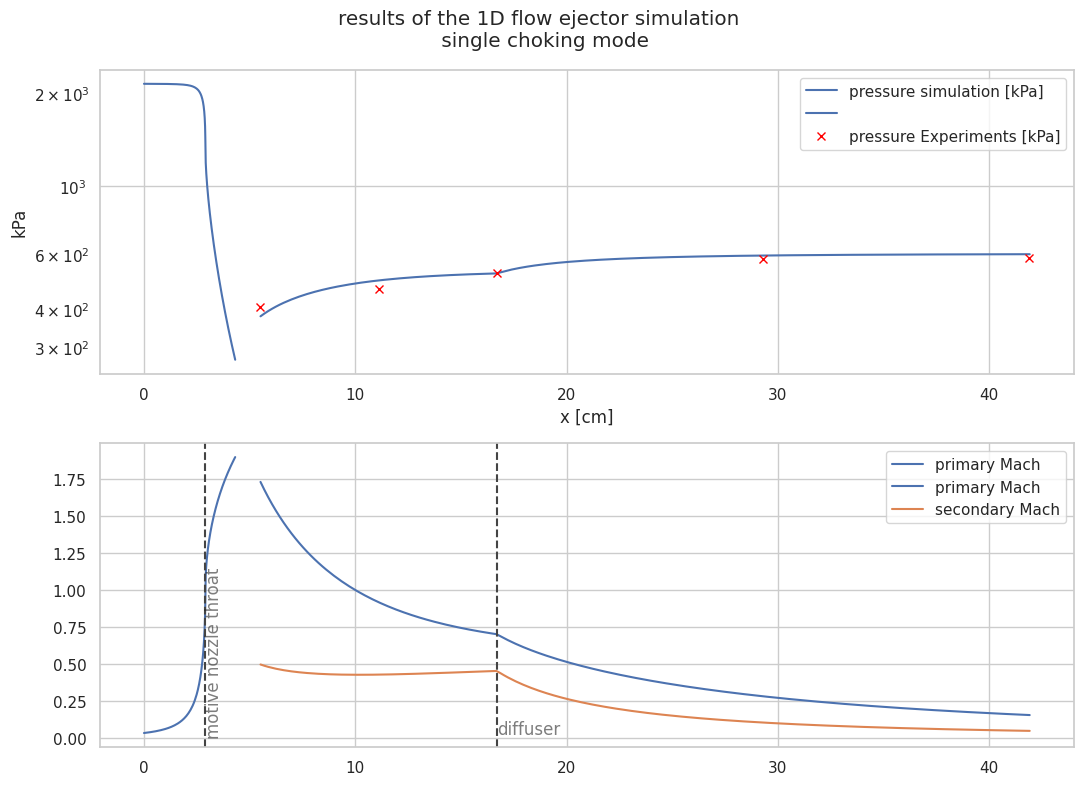

In [35]:
specPlotSolution(ejector, RP, res_crit, solMix, "single choking mode",  False, pressureExp)